# ICS 604: APPLIED DATA SCIENCE

## Data Wrangling: Groupby & Split-Apply-Combine

---

## Overview

In this section, we introduce the powerful `groupby()` method in Pandas, which is essential for analyzing and summarizing structured data. The `groupby()` operation allows you to organize data into groups based on one or more keys, enabling more targeted and meaningful analysis.

We will also explore the **split–apply–combine** paradigm that underlies `groupby`. This approach involves splitting the data into groups, applying an operation to each group, and then combining the results. Using this framework, you will learn how to:

* aggregate data within groups,
* transform values within each group,
* filter groups based on specific criteria, and
* thin the data to retain only relevant entries from each group.

In [1]:
import pandas as pd 

In [2]:
spending_df = pd.read_csv('data/spending_10k.csv', index_col="unique_id", dtype={"doctor_id": "object"})
spending_df.head(10)

,doctor_id,specialty,medication,nb_beneficiaries,spending
unique_id,,,,,
NX531425,1255626040,FAMILY PRACTICE,METFORMIN HCL,30,135.24
QG879256,1699761833,FAMILY PRACTICE,ALLOPURINOL,30,715.76
FW363228,1538148804,INTERNAL MEDICINE,LOSARTAN POTASSIUM,146,1056.47
WD733417,1730200619,PSYCHIATRY,OLANZAPINE,13,28226.97
XW149832,1023116894,FAMILY PRACTICE,PRAVASTATIN SODIUM,348,8199.48
QT485324,1952359671,FAMILY PRACTICE,HYDROCHLOROTHIAZIDE,57,247.01
NA293426,1841235223,FAMILY PRACTICE,SEVELAMER CARBONATE,11,4869.32
IF945618,1326095662,INTERNAL MEDICINE,FLUTICASONE/SALMETEROL,20,7832.46
PH384257,1821126830,HEMATOLOGY/ONCOLOGY,ZOLPIDEM TARTRATE,14,65.21


In [3]:
spending_df.shape

(10000, 5)

## `groupby` and `DataFrame` groups

The `groupby()` method in pandas is used to organize data into groups based on the values of one or more columns. By specifying one or more column labels, Pandas splits the DataFrame into subsets where all rows in each group share the same value for the grouping column(s).

In the example illustrated below, `df_1.groupby("X")` groups the DataFrame by the values in column `X`. The result is a `DataFrameGroupBy` object, which represents the grouped structure of the data. This object does not perform any computation by itself; instead, it serves as an intermediate step that allows you to apply aggregation, transformation, filtering, or other operations to each group independently.

<img src="https://www.dropbox.com/scl/fi/xyvtdocd7o1w93mpgx663/groupby.png?rlkey=m6blpidbu2g160rr88l7fe5rh&st=0h6qwc48&dl=1" alt="drawing" style="width:500px">

### Identifying Groups from a `GroupBy` Object

Calling `spending_df.groupby('specialty')` groups the rows of the DataFrame based on the values in the `specialty` column. Instead of immediately producing a new DataFrame, this operation returns a `DataFrameGroupBy` object, which represents the grouped structure of the data. Visually, you can think of it as a mapping from each unique specialty value to the subset of rows that belong to that group.

```python
spending_df.groupby('specialty')
```

<img src="https://www.dropbox.com/scl/fi/r8fv7wyus93c06kty7a29/group_by_specialty.png?rlkey=ycrmex2xpbbpj4nsc3lgb53ni&st=o8iybn7n&dl=1" alt="drawing" style="width:700px">

It is important to note that a `DataFrameGroupBy` object is not a DataFrame. As a result, it does not support the full set of DataFrame methods discussed earlier. Instead, it is an intermediate object designed specifically for group-wise operations such as aggregation, transformation, and filtering.

Individual groups can be accessed from a `DataFrameGroupBy` object by specifying a valid value (or combination of values) from the column(s) used for grouping. Each retrieved group is returned as a regular DataFrame, allowing you to inspect or manipulate the data within a specific group independently.



In [4]:
x = spending_df.groupby('specialty')
type(x)

pandas.core.groupby.generic.DataFrameGroupBy

In [5]:
spending_by_specialty = spending_df.groupby('specialty')

addiction_med_group = spending_by_specialty.get_group("ADDICTION MEDICINE")
addiction_med_group

,doctor_id,specialty,medication,nb_beneficiaries,spending
unique_id,,,,,
VG585760,1801032297,ADDICTION MEDICINE,LAMOTRIGINE,11,82.62
GJ278932,1134139991,ADDICTION MEDICINE,BUSPIRONE HCL,49,817.88
TX420809,1801032297,ADDICTION MEDICINE,LORAZEPAM,14,19.56


In [6]:
spending_by_specialty.get_group("GERIATRIC PSYCHIATRY")

,doctor_id,specialty,medication,nb_beneficiaries,spending
unique_id,,,,,
PI452198,1073619789,GERIATRIC PSYCHIATRY,CLOZAPINE,20,2280.71
WA740528,1396726584,GERIATRIC PSYCHIATRY,SERTRALINE HCL,298,1493.43
FU325338,1396759015,GERIATRIC PSYCHIATRY,QUETIAPINE FUMARATE,13,9318.09
CW959540,1598959595,GERIATRIC PSYCHIATRY,RISPERIDONE,183,4176.32


## `groupby` and Group-Specific Processing

A key use case for the `groupby` method is group-specific processing, where the same operation is applied independently to each group. This is especially useful when you want to summarize or analyze data at the group level rather than across the entire dataset.

For example, to compute the total spending by `specialty`, we need to perform the following steps:
* First, the data is split into groups based on the `specialty` column.
* Next, the `spending` values within each group are summed.
* Finally, the results from all groups are combined and returned as a new DataFrame, with one total spending value per specialty.

### Split-Apply-Combine Paradigm

The `groupby()` method is commonly used within the **split-apply-combine** paradigm, a structured approach for processing grouped data. In this paradigm, data is first split into chunks based on one or more column values, typically using `groupby()`. Next, operation(s) is(are) applied independently to each group, such as counting rows, summing values, or calculating averages. Finally, the results from each group are combined into a new DataFrame, producing a summary of the grouped data

<img src="https://www.dropbox.com/scl/fi/lws8rohxg8e0ixc2unecv/split_apply_combine_example.png?rlkey=up3ugwe99hg0dbh5axm0rxs3p&st=h1kf8zn4&dl=1" alt="drawing" style="width:600px">

An example of this approach is shown in the figure, where the data is grouped, a computation is applied to each group, and the results are collected into a new table. This specific type of split-apply-combine operation is known as *aggregation*, where group data is reduced to a single value per group, such as totals, means, or counts. Aggregation is one of the most common use cases for `groupby` in pandas.

### The 3 (or 3$\frac{1}{2}$) Classes of Operations on Groups

In the split-apply-combine framework, there are three main classes of operations on grouped data, along with a useful variant that we can think of as “half” a class, which helps to better classify group-level operations.

1. **Aggregations**

   Aggregations reduce the data in each group to a **single value**. Common examples include computing sums, means, maximums, or minimums for each group. For instance, you might sum the `spending` for each `specialty`. Aggregations are useful for generating concise summaries of group data.
   <img src="https://www.dropbox.com/scl/fi/aqt0s5w7knaswsst1cqpy/aggregate.png?rlkey=vbgdb03913nvdxl41r0ckfj2j&st=4611suty&dl=1" alt="drawing" style="width:700px">
   
2. **Transformations**

   Transformations apply a **group-specific operation** while keeping the number of entries the same as in the original group. For example, you might normalize spending values by dividing each entry by the total spending of its group, or convert currency for each country in a dataset. The resulting group maintains the same size, but the values are transformed according to some group-level logic. The figure illustrates dividing column `Y` by the group sum.

   <img src="https://www.dropbox.com/scl/fi/p28h157x7wgg3f23vi9rk/transform_2.png?rlkey=8upfcu7gmur4lwapd3ukh24yq&st=khfh5x5i&dl=1" alt="drawing" style="width:700px">

3. **Filtering**

   Filtering **retains or discards entire groups** based on a boolean condition computed at the group level. For example, you might drop all specialties whose total spending is below a certain threshold or retain only groups with enough entries. Groups that meet the condition are kept unmodified, while others are removed entirely. The figure shows filtering groups where the sum of column `Y` is less than 10.

   <img src="https://www.dropbox.com/scl/fi/c3p842le0uv5afwvfzah6/filter.png?rlkey=jgmgweplvteiuv8peeisa1k9p&st=wkr0d8q5&dl=1" alt="drawing" style="width:700px">

3$\frac{1}{2}$\. **Thinning** 

   Thinning is a variant operation that **reduces the number of entries within groups** based on group-specific logic. Unlike aggregation, thinning does not necessarily collapse a group into a single value. It can be used to subsample data within each group, retain the top `n` entries, or remove outliers based on the group mean. Thinning is especially useful for creating balanced datasets or selectively pruning group data while keeping the structure of the groups intact. The figure shows a thinning operation where only the entry with the largest Y value in each group is retained.

   <img src="https://www.dropbox.com/scl/fi/y01iry4zp4w1h6offojoq/thin.png?rlkey=vq30za9csly2l9e0r3m81h8pg&st=2y4sj493&dl=1" alt="drawing" style="width:700px">


Together, these classes — aggregation, transformation, filtering, and thinning — cover most of the common ways to process grouped data in pandas, providing flexible tools for both summarizing and reshaping datasets at the group level.

## Aggregating the Data Using `groupby`

Aggregation is a common use of groupby to compute summary statistics for each group. Once data is grouped, pandas provides a variety of aggregation methods to quickly summarize the groups.

Some key aggregation methods for `DataFrameGroupBy` objects include:

|Methods           |        Decription                              |
|:-----------------|:-----------------------------------------------|
| `mean`, `median` | Computes the mean or the median for each group | 
| `min` , `max`    | Computes the minimum or maximum for each group | 
| `size`           | Counts the number of values in each group      | 

These methods are applied to all valid columns in the grouped data, with the grouping column(s) used as the index. The syntax is simple and consistent:
 
```python
spending_df.groupby('specialty').sum()

# or

spending_df.groupby('specialty').min()
```

This allows you to quickly obtain group-level summaries across multiple columns in a single step.

In [7]:
df = pd.DataFrame({"A":[1, 1, 2, 2, 3, 3], "B":[1, 2, 3, 4, 5, 6], 
                   "C":["A", "B", "C", "D", "E", "F"]})
display(df)

df.groupby("A").sum()

,A,B,C
0,1,1,A
1,1,2,B
2,2,3,C
3,2,4,D
4,3,5,E
5,3,6,F


,B,C
A,,
1,3,AB
2,7,CD
3,11,EF


In [8]:
spending_df.head()

,doctor_id,specialty,medication,nb_beneficiaries,spending
unique_id,,,,,
NX531425,1255626040,FAMILY PRACTICE,METFORMIN HCL,30,135.24
QG879256,1699761833,FAMILY PRACTICE,ALLOPURINOL,30,715.76
FW363228,1538148804,INTERNAL MEDICINE,LOSARTAN POTASSIUM,146,1056.47
WD733417,1730200619,PSYCHIATRY,OLANZAPINE,13,28226.97
XW149832,1023116894,FAMILY PRACTICE,PRAVASTATIN SODIUM,348,8199.48


In [9]:
spending_df.groupby('specialty').sum().head(10)

,doctor_id,medication,nb_beneficiaries,spending
specialty,,,,
ADDICTION MEDICINE,180103229711341399911801032297,LAMOTRIGINEBUSPIRONE HCLLORAZEPAM,74,920.06
ALLERGY/IMMUNOLOGY,1104888403100389785118614997411720080062179085...,DEXLANSOPRAZOLEMOMETASONE FUROATEALBUTEROL SUL...,1063,189174.06
ANESTHESIOLOGY,1972509974140783819618918500121760454805118461...,HYDROCODONE/IBUPROFENATENOLOLHYDROMORPHONE HCL...,1673,142804.73
CARDIAC ELECTROPHYSIOLOGY,1710150693103321883918210567711538130034166958...,RIVAROXABANLISINOPRILRIVAROXABANFLECAINIDE ACE...,1041,225543.62
CARDIAC SURGERY,16896272671609804855,"INSULIN GLARGINE,HUM.REC.ANLOGHYDROCODONE/ACET...",33,12432.92
CARDIOLOGY,1013915552175038231316191814271801882386156846...,ESOMEPRAZOLE MAGNESIUMPOTASSIUM CHLORIDEPRAVAS...,29638,1915787.90
CERTIFIED CLINICAL NURSE SPECIALIST,1528385762152838576216897420741437306941182115...,METOPROLOL SUCCINATEMETFORMIN HCLROPINIROLE HC...,1146,114057.40
CERTIFIED NURSE MIDWIFE,16290689601942202890,MIRABEGRONMEDROXYPROGESTERONE ACETATE,58,14763.47
CLINIC/CENTER,17606802431730415829,ESOMEPRAZOLE MAGNESIUMMIRTAZAPINE,23,3110.16


### Applying Functions to Group Columns

When simple built-in aggregation methods are not sufficient, pandas provides the `agg()` method for custom or more complex aggregation logic. Here, the `agg()` method is applied to a `DataFrameGroupBy` object and allows you to specify one or more functions that are used to aggregate the data within each group.

The `agg()` method can accept a single function or a list of functions. In the example shown, a custom function `sum_spending_CAD` is defined to compute total spending and convert it to Canadian dollars. Applying this function with `agg()` aggregates the `spending` column for each group using the custom logic.


In [10]:
def sum_spending_CAD(x):
    return x.sum() * 1.39

spending_by_specialty['spending'].agg(sum_spending_CAD)

specialty
ADDICTION MEDICINE                                                  1278.8834
ALLERGY/IMMUNOLOGY                                                262951.9434
ANESTHESIOLOGY                                                    198498.5747
CARDIAC ELECTROPHYSIOLOGY                                         313505.6318
CARDIAC SURGERY                                                    17281.7588
                                                                     ...     
STUDENT IN AN ORGANIZED HEALTH CARE EDUCATION/TRAINING PROGRAM     29617.0775
THORACIC SURGERY                                                     261.5980
UNKNOWN PHYSICIAN SPECIALTY CODE                                    5744.4391
UROLOGY                                                           490752.7884
VASCULAR SURGERY                                                    6070.3802
Name: spending, Length: 75, dtype: float64

In addition, `agg()` can take a **dictionary** that maps column names to aggregation functions, which is required when aggregating multiple columns with different operations.

In [11]:
def sum_spending_CAD(x):
    return x.sum() * 1.39

spending_by_specialty.agg({'nb_beneficiaries': "sum", 
                           'spending': sum_spending_CAD}).head()

,nb_beneficiaries,spending
specialty,,
ADDICTION MEDICINE,74,1278.8834
ALLERGY/IMMUNOLOGY,1063,262951.9434
ANESTHESIOLOGY,1673,198498.5747
CARDIAC ELECTROPHYSIOLOGY,1041,313505.6318
CARDIAC SURGERY,33,17281.7588


Finally, `agg()` can also take a **list of functions**, applying each function to the specified columns and returning multiple aggregated statistics per group. 

In [12]:
spending_by_specialty.agg(["min", "max", "sum"]).head()

doctor_id              \
                                  min         max   
specialty                                           
ADDICTION MEDICINE         1134139991  1801032297   
ALLERGY/IMMUNOLOGY         1003812595  1962588053   
ANESTHESIOLOGY             1013069699  1972509974   
CARDIAC ELECTROPHYSIOLOGY  1013904093  1962479527   
CARDIAC SURGERY            1609804855  1689627267   

                                                                              \
                                                                         sum   
specialty                                                                      
ADDICTION MEDICINE                            180103229711341399911801032297   
ALLERGY/IMMUNOLOGY         1104888403100389785118614997411720080062179085...   
ANESTHESIOLOGY             1972509974140783819618918500121760454805118461...   
CARDIAC ELECTROPHYSIOLOGY  1710150693103321883918210567711538130034166958...   
CARDIAC SURGERY                                         16896272671609804855   

                                          medication  \
                                                 min   
specialty                                              
ADDICTION MEDICINE                     BUSPIRONE HCL   
ALLERGY/IMMUNOLOGY                 ALBUTEROL SULFATE   
ANESTHESIOLOGY                           AMOXICILLIN   
CARDIAC ELECTROPHYSIOLOGY                   ATENOLOL   
CARDIAC SURGERY            HYDROCODONE/ACETAMINOPHEN   

                                                           \
                                                      max   
specialty                                                   
ADDICTION MEDICINE                              LORAZEPAM   
ALLERGY/IMMUNOLOGY                TRIAMCINOLONE ACETONIDE   
ANESTHESIOLOGY                          ZOLPIDEM TARTRATE   
CARDIAC ELECTROPHYSIOLOGY                 WARFARIN SODIUM   
CARDIAC SURGERY            INSULIN GLARGINE,HUM.REC.ANLOG   

                                                                              \
                                                                         sum   
specialty                                                                      
ADDICTION MEDICINE                         LAMOTRIGINEBUSPIRONE HCLLORAZEPAM   
ALLERGY/IMMUNOLOGY         DEXLANSOPRAZOLEMOMETASONE FUROATEALBUTEROL SUL...   
ANESTHESIOLOGY             HYDROCODONE/IBUPROFENATENOLOLHYDROMORPHONE HCL...   
CARDIAC ELECTROPHYSIOLOGY  RIVAROXABANLISINOPRILRIVAROXABANFLECAINIDE ACE...   
CARDIAC SURGERY            INSULIN GLARGINE,HUM.REC.ANLOGHYDROCODONE/ACET...   

                          nb_beneficiaries            spending            \
                                       min  max   sum      min       max   
specialty                                                                  
ADDICTION MEDICINE                      11   49    74    19.56    817.88   
ALLERGY/IMMUNOLOGY                      11  297  1063   109.80  52389.61   
ANESTHESIOLOGY                          12  419  1673    35.33  34073.91   
CARDIAC ELECTROPHYSIOLOGY               12  188  1041    69.85  89101.54   
CARDIAC SURGERY                         15   18    33   442.91  11990.01   

                                      
                                 sum  
specialty                             
ADDICTION MEDICINE            920.06  
ALLERGY/IMMUNOLOGY         189174.06  
ANESTHESIOLOGY             142804.73  
CARDIAC ELECTROPHYSIOLOGY  225543.62  
CARDIAC SURGERY             12432.92

In [13]:
# note that sum, min and max here are functions
spending_by_specialty[['spending', 'nb_beneficiaries']].agg(["sum", "min", "max"]).head()

spending                   nb_beneficiaries      \
                                 sum     min       max              sum min   
specialty                                                                     
ADDICTION MEDICINE            920.06   19.56    817.88               74  11   
ALLERGY/IMMUNOLOGY         189174.06  109.80  52389.61             1063  11   
ANESTHESIOLOGY             142804.73   35.33  34073.91             1673  12   
CARDIAC ELECTROPHYSIOLOGY  225543.62   69.85  89101.54             1041  12   
CARDIAC SURGERY             12432.92  442.91  11990.01               33  15   

                                
                           max  
specialty                       
ADDICTION MEDICINE          49  
ALLERGY/IMMUNOLOGY         297  
ANESTHESIOLOGY             419  
CARDIAC ELECTROPHYSIOLOGY  188  
CARDIAC SURGERY             18

In [14]:
# same operation as above
func_list = ["sum", "min", "max"]

spending_by_specialty.agg({'spending': func_list, 
                           'nb_beneficiaries': func_list}).head()

spending                   nb_beneficiaries      \
                                 sum     min       max              sum min   
specialty                                                                     
ADDICTION MEDICINE            920.06   19.56    817.88               74  11   
ALLERGY/IMMUNOLOGY         189174.06  109.80  52389.61             1063  11   
ANESTHESIOLOGY             142804.73   35.33  34073.91             1673  12   
CARDIAC ELECTROPHYSIOLOGY  225543.62   69.85  89101.54             1041  12   
CARDIAC SURGERY             12432.92  442.91  11990.01               33  15   

                                
                           max  
specialty                       
ADDICTION MEDICINE          49  
ALLERGY/IMMUNOLOGY         297  
ANESTHESIOLOGY             419  
CARDIAC ELECTROPHYSIOLOGY  188  
CARDIAC SURGERY             18

In [15]:
spending_by_specialty.agg({'nb_beneficiaries': "min",
                           'spending': "max"}).head()

,nb_beneficiaries,spending
specialty,,
ADDICTION MEDICINE,11,817.88
ALLERGY/IMMUNOLOGY,11,52389.61
ANESTHESIOLOGY,12,34073.91
CARDIAC ELECTROPHYSIOLOGY,12,89101.54
CARDIAC SURGERY,15,11990.01


In [16]:
spending_by_specialty.agg({'nb_beneficiaries': ["min", "sum"],
                           'spending': "max"}).head()

nb_beneficiaries        spending
                                       min   sum       max
specialty                                                 
ADDICTION MEDICINE                      11    74    817.88
ALLERGY/IMMUNOLOGY                      11  1063  52389.61
ANESTHESIOLOGY                          12  1673  34073.91
CARDIAC ELECTROPHYSIOLOGY               12  1041  89101.54
CARDIAC SURGERY                         15    33  11990.01

## Transforming  the Data in `groupby`

Unlike aggregations, which reduce each group to a single summary value, transformations modify the data within each group **without changing the group’s `shape` or size**. Each input row produces exactly one output row, preserving the original structure of the data.

Transformations are especially useful when applying group-specific operations, where the computation depends on the values within each group but the results must align with the original rows. In the example shown, the transformation computes the percent contribution of each entry to its specialty by normalizing each spending value by the total spending for that specialty. This allows each row to be interpreted in the context of its group while retaining the full dataset structure.

<img src="https://www.dropbox.com/scl/fi/laui9tn92a2ns1hy1zszw/transform_spending.png?rlkey=uj360lg1l49t57jtozqjen07v&st=iyfm7s0y&dl=1" alt="drawing" style="width:1200px">

### Applying a Transformation

Applying a transformation in pandas is done using the `transform()` method. This method operates on a `DataFrameGroupBy` object and applies a specified function independently to each group.

The function passed to `transform()` is applied to the group’s data and must return an output that has the same shape as the original group. This ensures that the transformed results align one-to-one with the original rows..

In [17]:
def my_function(x):
    return (x / x.sum()) * 100
    
spending_by_specialty['spending'].transform(my_function).head()

unique_id
NX531425    0.002075
QG879256    0.010985
FW363228    0.010855
WD733417    1.614442
XW149832    0.125835
Name: spending, dtype: float64

In [18]:
spending_df["spending_pct"] = spending_by_specialty['spending'].transform(my_function)

spending_df.head()

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
NX531425,1255626040,FAMILY PRACTICE,METFORMIN HCL,30,135.24,0.002075
QG879256,1699761833,FAMILY PRACTICE,ALLOPURINOL,30,715.76,0.010985
FW363228,1538148804,INTERNAL MEDICINE,LOSARTAN POTASSIUM,146,1056.47,0.010855
WD733417,1730200619,PSYCHIATRY,OLANZAPINE,13,28226.97,1.614442
XW149832,1023116894,FAMILY PRACTICE,PRAVASTATIN SODIUM,348,8199.48,0.125835


In [19]:
spending_df[spending_df['specialty'] == "ADDICTION MEDICINE"]

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
VG585760,1801032297,ADDICTION MEDICINE,LAMOTRIGINE,11,82.62,8.979849
GJ278932,1134139991,ADDICTION MEDICINE,BUSPIRONE HCL,49,817.88,88.894203
TX420809,1801032297,ADDICTION MEDICINE,LORAZEPAM,14,19.56,2.125948


In [20]:
spending_df.sort_values(['specialty', 'spending_pct'], ascending=[True, False]).head(10)

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
GJ278932,1134139991,ADDICTION MEDICINE,BUSPIRONE HCL,49,817.88,88.894203
VG585760,1801032297,ADDICTION MEDICINE,LAMOTRIGINE,11,82.62,8.979849
TX420809,1801032297,ADDICTION MEDICINE,LORAZEPAM,14,19.56,2.125948
XY715196,1376691626,ALLERGY/IMMUNOLOGY,FLUTICASONE/SALMETEROL,102,52389.61,27.693866
DL492570,1962588053,ALLERGY/IMMUNOLOGY,OMALIZUMAB,12,29153.71,15.411051
UJ888112,1003897851,ALLERGY/IMMUNOLOGY,MOMETASONE FUROATE,55,20759.04,10.973513
GO641321,1255301404,ALLERGY/IMMUNOLOGY,FLUTICASONE/SALMETEROL,35,14277.61,7.547340
JU235992,1003812595,ALLERGY/IMMUNOLOGY,MOMETASONE FUROATE,50,13559.50,7.167737
WE196352,1720080062,ALLERGY/IMMUNOLOGY,FLUTICASONE/SALMETEROL,37,12594.63,6.657694


### More Complex Transformations

In more complex scenarios, transformations may reveal additional structure in the data. In this case, individual drugs are still duplicated across multiple `doctor_id`s within the same `specialty`. For example, `FLUTICASONE/SALMETEROL` may be prescribed by several doctors who all share the specialty `ALLERGY/IMMUNOLOGY`, resulting in multiple entries for the same drug within that specialty.

To compute the percent spending by drug, these duplicate entries must be combined. This is done by grouping the data on both `specialty` and `medication`, and then summing the previously computed `spending_pct` values. The result is a breakdown of total spending percentage for each medication within each specialty as shown below.

In [21]:
medication_spending_pct = (spending_df
    .groupby(["specialty", "medication"])["spending_pct"]
    .sum())
medication_spending_pct.head(15)

specialty           medication                
ADDICTION MEDICINE  BUSPIRONE HCL                 88.894203
                    LAMOTRIGINE                    8.979849
                    LORAZEPAM                      2.125948
ALLERGY/IMMUNOLOGY  ALBUTEROL SULFATE              3.553199
                    AMOXICILLIN/POTASSIUM CLAV     0.196089
                    AZELASTINE HCL                 3.646451
                    AZITHROMYCIN                   0.100500
                    DEXLANSOPRAZOLE                6.561111
                    DILTIAZEM HCL                  0.293666
                    DOXAZOSIN MESYLATE             0.104872
                    ENALAPRIL MALEATE              0.318553
                    FLUTICASONE PROPIONATE         2.842509
                    FLUTICASONE/SALMETEROL        41.898900
                    HYDROXYZINE HCL                0.135473
                    IRBESARTAN                     0.058042
Name: spending_pct, dtype: float64

In [22]:
medication_spending_pct.index

MultiIndex([('ADDICTION MEDICINE',                 'BUSPIRONE HCL'),
            ('ADDICTION MEDICINE',                   'LAMOTRIGINE'),
            ('ADDICTION MEDICINE',                     'LORAZEPAM'),
            ('ALLERGY/IMMUNOLOGY',             'ALBUTEROL SULFATE'),
            ('ALLERGY/IMMUNOLOGY',    'AMOXICILLIN/POTASSIUM CLAV'),
            ('ALLERGY/IMMUNOLOGY',                'AZELASTINE HCL'),
            ('ALLERGY/IMMUNOLOGY',                  'AZITHROMYCIN'),
            ('ALLERGY/IMMUNOLOGY',               'DEXLANSOPRAZOLE'),
            ('ALLERGY/IMMUNOLOGY',                 'DILTIAZEM HCL'),
            ('ALLERGY/IMMUNOLOGY',            'DOXAZOSIN MESYLATE'),
            ...
            (           'UROLOGY',            'SILDENAFIL CITRATE'),
            (           'UROLOGY', 'SULFAMETHOXAZOLE/TRIMETHOPRIM'),
            (           'UROLOGY',                     'TADALAFIL'),
            (           'UROLOGY',                'TAMSULOSIN HCL'),
            (     

### Pandas `MultiIndex`

When grouping data by more than one column, the result uses a **`MultiIndex`**. A MultiIndex is an index composed of multiple levels, with each level corresponding to one of the columns used in the grouping. This allows Pandas to represent hierarchical relationships in the data, such as values grouped by both `specialty` and `medication`.

Indexing into a Series or DataFrame with a `MultiIndex` requires specifying a **tuple of index values**, with one element per index level (or at least the leading levels). This tuple-based indexing makes it possible to precisely select data at different levels of the hierarchy, as illustrated in the figure.

<img src="https://www.dropbox.com/scl/fi/j38wq9amhspwmdssv80u0/multi_index.png?rlkey=kqiep1xpxy8sstjho32gj5m52&st=09am72f5&dl=1" alt="drawing" style="width:600px">

In [23]:
df = pd.DataFrame([[1, 1, 1], [1, 2, 2], [2, 1, 3], [2, 2, 4]], columns=["A", "B", "C"])
df

,A,B,C
0,1,1,1
1,1,2,2
2,2,1,3
3,2,2,4


In [24]:
df = df.set_index(["A", "B"])
df.index

MultiIndex([(1, 1),
            (1, 2),
            (2, 1),
            (2, 2)],
           names=['A', 'B'])

In [25]:
df

C
A B   
1 1  1
  2  2
2 1  3
  2  4

In [26]:
medication_spending_pct[('ADDICTION MEDICINE', 'BUSPIRONE HCL')]

np.float64(88.89420255200748)

In [27]:
medication_spending_pct[('ADDICTION MEDICINE', )]

medication
BUSPIRONE HCL    88.894203
LAMOTRIGINE       8.979849
LORAZEPAM         2.125948
Name: spending_pct, dtype: float64

In [28]:
medication_spending_pct[('ADDICTION MEDICINE', )].sum()

np.float64(100.0)

In [29]:
medication_spending_pct[('ALLERGY/IMMUNOLOGY', )]

medication
ALBUTEROL SULFATE                  3.553199
AMOXICILLIN/POTASSIUM CLAV         0.196089
AZELASTINE HCL                     3.646451
AZITHROMYCIN                       0.100500
DEXLANSOPRAZOLE                    6.561111
DILTIAZEM HCL                      0.293666
DOXAZOSIN MESYLATE                 0.104872
ENALAPRIL MALEATE                  0.318553
FLUTICASONE PROPIONATE             2.842509
FLUTICASONE/SALMETEROL            41.898900
HYDROXYZINE HCL                    0.135473
IRBESARTAN                         0.058042
LEVOCETIRIZINE DIHYDROCHLORIDE     1.200698
MOMETASONE FUROATE                18.141250
MOMETASONE/FORMOTEROL              2.566123
OMALIZUMAB                        15.411051
PREGABALIN                         2.679754
RANITIDINE HCL                     0.091477
TRIAMCINOLONE ACETONIDE            0.200281
Name: spending_pct, dtype: float64

In [30]:
medication_spending_pct[('ALLERGY/IMMUNOLOGY', )].sum()

np.float64(100.0)

While a `MultiIndex` is useful for representing hierarchical data, it can sometimes be inconvenient to work with, or you may prefer to index the data using a different column. In such cases, Pandas allows you to remove the `MultiIndex` and return to a standard index.

This can be done using the `reset_index()` method. Calling `reset_index()` converts the `MultiIndex` levels into regular columns and replaces the index with a default range index (from 0 to n−1). This makes it easier to perform operations such as sorting or filtering — for example, sorting the data by `specialty` and `spending_pct` as done earlier.

In [31]:
spending_df.groupby(["specialty", "medication"])["spending_pct"].sum().head(10)

specialty           medication                
ADDICTION MEDICINE  BUSPIRONE HCL                 88.894203
                    LAMOTRIGINE                    8.979849
                    LORAZEPAM                      2.125948
ALLERGY/IMMUNOLOGY  ALBUTEROL SULFATE              3.553199
                    AMOXICILLIN/POTASSIUM CLAV     0.196089
                    AZELASTINE HCL                 3.646451
                    AZITHROMYCIN                   0.100500
                    DEXLANSOPRAZOLE                6.561111
                    DILTIAZEM HCL                  0.293666
                    DOXAZOSIN MESYLATE             0.104872
Name: spending_pct, dtype: float64

In [32]:
medication_spending_pct = spending_df.groupby(["specialty", "medication"])["spending_pct"].sum().reset_index()
medication_spending_pct.head(10)

,specialty,medication,spending_pct
0,ADDICTION MEDICINE,BUSPIRONE HCL,88.894203
1,ADDICTION MEDICINE,LAMOTRIGINE,8.979849
2,ADDICTION MEDICINE,LORAZEPAM,2.125948
3,ALLERGY/IMMUNOLOGY,ALBUTEROL SULFATE,3.553199
4,ALLERGY/IMMUNOLOGY,AMOXICILLIN/POTASSIUM CLAV,0.196089
5,ALLERGY/IMMUNOLOGY,AZELASTINE HCL,3.646451
6,ALLERGY/IMMUNOLOGY,AZITHROMYCIN,0.100500
7,ALLERGY/IMMUNOLOGY,DEXLANSOPRAZOLE,6.561111
8,ALLERGY/IMMUNOLOGY,DILTIAZEM HCL,0.293666
9,ALLERGY/IMMUNOLOGY,DOXAZOSIN MESYLATE,0.104872


In [33]:
medication_spending_pct.shape

(2779, 3)

In [34]:
medication_spending_pct.sort_values(["specialty", "spending_pct"], ascending=[True, False]).head(10)

,specialty,medication,spending_pct
0,ADDICTION MEDICINE,BUSPIRONE HCL,88.894203
1,ADDICTION MEDICINE,LAMOTRIGINE,8.979849
2,ADDICTION MEDICINE,LORAZEPAM,2.125948
12,ALLERGY/IMMUNOLOGY,FLUTICASONE/SALMETEROL,41.898900
16,ALLERGY/IMMUNOLOGY,MOMETASONE FUROATE,18.141250
18,ALLERGY/IMMUNOLOGY,OMALIZUMAB,15.411051
7,ALLERGY/IMMUNOLOGY,DEXLANSOPRAZOLE,6.561111
5,ALLERGY/IMMUNOLOGY,AZELASTINE HCL,3.646451
3,ALLERGY/IMMUNOLOGY,ALBUTEROL SULFATE,3.553199
11,ALLERGY/IMMUNOLOGY,FLUTICASONE PROPIONATE,2.842509


## Filtering Groups

Filtering groups in pandas is done using the `filter()` method. This method operates on a `DataFrameGroupBy` object and applies a user-defined function to each group.

The function passed to `filter()` must return a Boolean value (`True` or `False`). If the function returns `True`, the group is kept; if it returns `False`, the entire group is dropped from the result. Importantly, `filter()` does not modify the data within retained groups — it only determines which groups to keep.

The resulting DataFrame preserves the original row order from the input DataFrame, making it easy to apply group-level filtering without disrupting the overall data structure.

In [35]:
df = pd.DataFrame([[1, 1], [1, 2], [2, 3], [2, 4]], columns=["A", "B"])
df

,A,B
0,1,1
1,1,2
2,2,3
3,2,4


In [36]:
df.groupby("A").filter(lambda x: x["B"].sum() > 4)

,A,B
2,2,3
3,2,4


In [37]:
print(len(spending_df['specialty'].unique()))
spending_df['specialty'].unique()[:20]

75


array(['FAMILY PRACTICE', 'INTERNAL MEDICINE', 'PSYCHIATRY',
       'HEMATOLOGY/ONCOLOGY', 'OPHTHALMOLOGY', 'NEUROLOGY',
       'NURSE PRACTITIONER', 'NEPHROLOGY', 'DENTIST', 'SPECIALIST',
       'GENERAL PRACTICE', 'INTERVENTIONAL CARDIOLOGY',
       'OBSTETRICS/GYNECOLOGY', 'PHYSICIAN ASSISTANT', 'CARDIOLOGY',
       'ENDOCRINOLOGY', 'RHEUMATOLOGY', 'OPTOMETRY',
       'STUDENT IN AN ORGANIZED HEALTH CARE EDUCATION/TRAINING PROGRAM',
       'PULMONARY DISEASE'], dtype=object)

In [38]:
def filter_on_spending(x):
    return x['spending'].sum() > 50_000


high_spending_df = (spending_df[["specialty", 'spending']]
    .groupby('specialty')
    .filter(filter_on_spending))

print(len(high_spending_df['specialty'].unique()))
high_spending_df['specialty'].unique()[:20]

38


array(['FAMILY PRACTICE', 'INTERNAL MEDICINE', 'PSYCHIATRY',
       'HEMATOLOGY/ONCOLOGY', 'OPHTHALMOLOGY', 'NEUROLOGY',
       'NURSE PRACTITIONER', 'NEPHROLOGY', 'GENERAL PRACTICE',
       'INTERVENTIONAL CARDIOLOGY', 'OBSTETRICS/GYNECOLOGY',
       'PHYSICIAN ASSISTANT', 'CARDIOLOGY', 'ENDOCRINOLOGY',
       'RHEUMATOLOGY', 'OPTOMETRY', 'PULMONARY DISEASE', 'DERMATOLOGY',
       'INTERVENTIONAL PAIN MANAGEMENT', 'PSYCHIATRY & NEUROLOGY'],
      dtype=object)

In [39]:
high_spending_df

,specialty,spending
unique_id,,
NX531425,FAMILY PRACTICE,135.24
QG879256,FAMILY PRACTICE,715.76
FW363228,INTERNAL MEDICINE,1056.47
WD733417,PSYCHIATRY,28226.97
XW149832,FAMILY PRACTICE,8199.48
...,...,...
ZK471712,FAMILY PRACTICE,467.35
QM412803,GASTROENTEROLOGY,479.59
NN242894,FAMILY PRACTICE,77.55


## Thinning Groups

Thinning groups refers to **reducing the number of entries within each group** while keeping the group structure intact. Unlike aggregation, thinning does not require collapsing a group into a single value — although in some cases it may do so.

Thinning is useful when you want to keep only the most relevant or representative entries from each group. Common use cases include selecting the top `n` entries per category, randomly sampling a subset of entries from each group, or trimming groups to create a more balanced dataset.

### Thinning Methods and `apply()`

Pandas provides several built-in methods that are useful for thinning grouped data, such as `nlargest()` and `nsmallest()`, which select the top or bottom entries within each group based on a specified column.

More generally, thinning is often performed using the `apply()` method. The `apply()` method operates on a `DataFrameGroupBy` object and takes a function as input, which is then called independently on each group. This allows you to implement flexible, custom thinning logic, such as selecting the top n entries, sampling rows, or applying domain-specific rules to reduce the size of each group.

In [40]:
spending_by_specialty['spending'].nsmallest(3)

specialty           unique_id
ADDICTION MEDICINE  TX420809       19.56
                    VG585760       82.62
                    GJ278932      817.88
ALLERGY/IMMUNOLOGY  HQ120242      109.80
                    HN843226      173.05
                                  ...   
UROLOGY             VI631849       36.07
                    UK512406       79.76
                    IE290947       93.30
VASCULAR SURGERY    CU764903       57.59
                    KL360002     4309.59
Name: spending, Length: 201, dtype: float64

In [41]:
spending_by_specialty['spending'].nlargest(3)

specialty           unique_id
ADDICTION MEDICINE  GJ278932       817.88
                    VG585760        82.62
                    TX420809        19.56
ALLERGY/IMMUNOLOGY  XY715196     52389.61
                    DL492570     29153.71
                                   ...   
UROLOGY             XR127617     97962.00
                    IW761955     74482.73
                    RY513742     28282.76
VASCULAR SURGERY    KL360002      4309.59
                    CU764903        57.59
Name: spending, Length: 201, dtype: float64

In [42]:
# implementation of nlargest using apply
(spending_by_specialty['spending']
    .apply(lambda x: x.sort_values(ascending=False).head(3))
)

specialty           unique_id
ADDICTION MEDICINE  GJ278932       817.88
                    VG585760        82.62
                    TX420809        19.56
ALLERGY/IMMUNOLOGY  XY715196     52389.61
                    DL492570     29153.71
                                   ...   
UROLOGY             XR127617     97962.00
                    IW761955     74482.73
                    RY513742     28282.76
VASCULAR SURGERY    KL360002      4309.59
                    CU764903        57.59
Name: spending, Length: 201, dtype: float64

### Sub-sampling a DataFrame

Subsampling is the process of selecting a random subset of rows from a DataFrame. It is commonly used to reduce dataset size or to create more balanced samples for analysis and modeling.

In pandas, subsampling is performed using the `sample()` method. This method allows you to specify either `n`, the exact number of rows to randomly select, or `frac`, the fraction of the dataset to return. For example,

```python
spending_df.sample(frac=0.001)
``` 

returns `0.1%` of the original DataFrame, selected at random.

Subsampling is especially useful when working with large datasets or when the data is imbalanced across certain factors, as it allows you to create smaller, more representative subsets without processing the entire dataset.

In [43]:
# return 1% of the data, i.e., 100 entries

spending_df.sample(frac=0.01)

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
JT618979,1033172499,INTERNAL MEDICINE,METOPROLOL TARTRATE,16,92.15,0.000947
XB791519,1588865075,ENDOCRINOLOGY,CANAGLIFLOZIN,53,26824.20,2.311043
ML178456,1063454015,FAMILY PRACTICE,BUPROPION HCL,66,2118.28,0.032509
JM997570,1528009461,INTERNAL MEDICINE,"PEN NEEDLE, DIABETIC",20,770.86,0.007920
WU185215,1013138254,PEDIATRIC MEDICINE,FUROSEMIDE,14,42.28,0.008104
...,...,...,...,...,...,...
YR791944,1720027477,FAMILY PRACTICE,ALPRAZOLAM,209,1030.40,0.015813
BH176437,1013955988,FAMILY PRACTICE,AMIODARONE HCL,25,173.20,0.002658
XZ845238,1568586014,FAMILY PRACTICE,ALENDRONATE SODIUM,80,431.56,0.006623


In [44]:
spending_df.sample(n=10) 

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
IF935320,1699736538,FAMILY PRACTICE,ALLOPURINOL,161,1554.09,0.023850
GX119596,1194823724,PHYSICIAN ASSISTANT,BUPROPION HCL,11,296.10,0.024823
IK471476,1396937751,NURSE PRACTITIONER,TRIHEXYPHENIDYL HCL,25,143.84,0.004308
LU692579,1457374290,INTERNAL MEDICINE,SUCRALFATE,19,552.77,0.005679
FA333286,1447300173,FAMILY PRACTICE,"FENOFIBRATE,MICRONIZED",47,5083.19,0.078010
RI372809,1447358270,INTERNAL MEDICINE,ISOSORBIDE MONONITRATE,13,227.61,0.002339
OK384783,1245265131,INTERNAL MEDICINE,ESCITALOPRAM OXALATE,56,1127.75,0.011587
FM540741,1063417822,INTERNAL MEDICINE,SULFAMETHOXAZOLE/TRIMETHOPRIM,52,506.76,0.005207
VN624694,1336394956,INTERNAL MEDICINE,VALSARTAN,12,312.75,0.003213


In [45]:
spending_df.groupby('specialty').size()

specialty
ADDICTION MEDICINE                                                 3
ALLERGY/IMMUNOLOGY                                                24
ANESTHESIOLOGY                                                    30
CARDIAC ELECTROPHYSIOLOGY                                         20
CARDIAC SURGERY                                                    2
                                                                  ..
STUDENT IN AN ORGANIZED HEALTH CARE EDUCATION/TRAINING PROGRAM    40
THORACIC SURGERY                                                   2
UNKNOWN PHYSICIAN SPECIALTY CODE                                   4
UROLOGY                                                           59
VASCULAR SURGERY                                                   2
Length: 75, dtype: int64

In [46]:
spending_df.groupby('specialty').size().sum()

np.int64(10000)

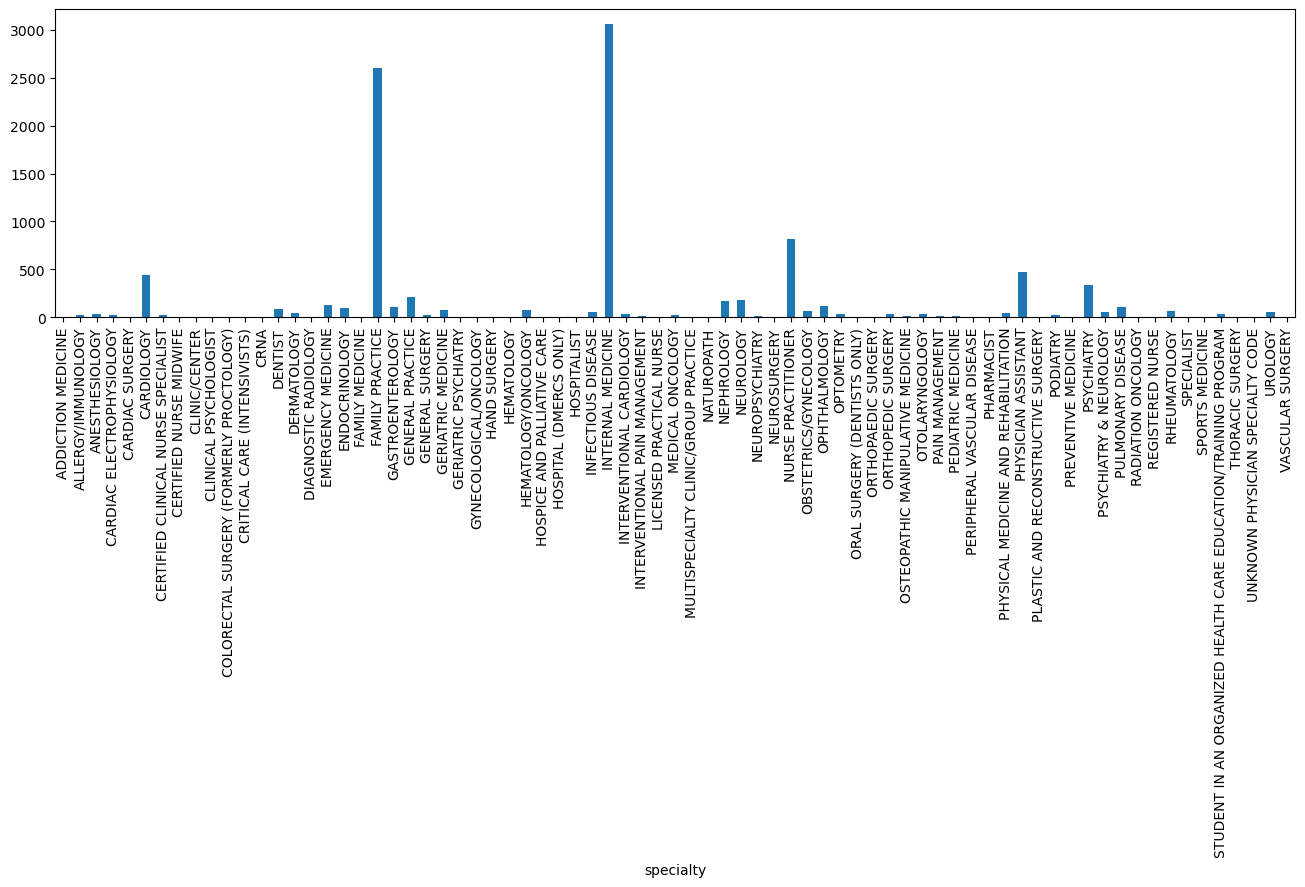

In [47]:
spending_df.groupby('specialty').size().plot.bar(figsize=(16, 4));

In [48]:
print(spending_by_specialty.get_group("CARDIOLOGY").shape)
spending_by_specialty.get_group("CARDIOLOGY")

(445, 6)


,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
VE177644,1013915552,CARDIOLOGY,ESOMEPRAZOLE MAGNESIUM,30,10604.67,0.553541
BZ839028,1750382313,CARDIOLOGY,POTASSIUM CHLORIDE,44,916.65,0.047847
LC673466,1619181427,CARDIOLOGY,PRAVASTATIN SODIUM,11,591.50,0.030875
HI410789,1801882386,CARDIOLOGY,METOPROLOL TARTRATE,305,2065.75,0.107828
SK725155,1568469666,CARDIOLOGY,VERAPAMIL HCL,50,848.85,0.044308
...,...,...,...,...,...,...
ES876044,1225098114,CARDIOLOGY,METOPROLOL SUCCINATE,139,5367.13,0.280153
XO536859,1225309685,CARDIOLOGY,FLECAINIDE ACETATE,37,1205.73,0.062937
HY883640,1912984279,CARDIOLOGY,PROPAFENONE HCL,13,295.67,0.015433


In [49]:
spending_by_specialty.get_group("CARDIOLOGY").sample(n=10)

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
QB553762,1861614638,CARDIOLOGY,ATORVASTATIN CALCIUM,11,2025.22,0.105712
BQ517103,1407843907,CARDIOLOGY,CHLORTHALIDONE,148,7887.90,0.411731
SO806183,1093926081,CARDIOLOGY,LOSARTAN/HYDROCHLOROTHIAZIDE,12,47.90,0.002500
GB221745,1841267846,CARDIOLOGY,ISOSORBIDE MONONITRATE,78,1072.94,0.056005
DU295985,1659363919,CARDIOLOGY,NIACIN,11,1447.62,0.075563
GE545024,1609923598,CARDIOLOGY,DIGOXIN,27,1188.99,0.062063
YX649438,1609839695,CARDIOLOGY,ISOSORBIDE DINITRATE,14,1122.49,0.058592
OJ429285,1013997741,CARDIOLOGY,DIGOXIN,134,5317.19,0.277546
RD375394,1265438253,CARDIOLOGY,ATENOLOL,36,267.57,0.013967


In [50]:
# We sample only 10% of the data in each category

def sample_10p(x):
    return x.sample(frac=0.1, replace=True)
    
spending_subsampled_10p = spending_by_specialty.apply(sample_10p, include_groups=False)
spending_subsampled_10p.head(10)

doctor_id               medication  \
specialty                 unique_id                                        
ALLERGY/IMMUNOLOGY        SG448787   1558363358  TRIAMCINOLONE ACETONIDE   
                          HN843226   1912909599           RANITIDINE HCL   
ANESTHESIOLOGY            RF491526   1356658389         MORPHINE SULFATE   
                          GK755216   1427168574     LEVOTHYROXINE SODIUM   
                          OG654287   1407838196                 ATENOLOL   
CARDIAC ELECTROPHYSIOLOGY MZ957454   1164530739                 ATENOLOL   
                          RV225361   1437213337          DRONEDARONE HCL   
CARDIOLOGY                OQ146068   1346276557     ATORVASTATIN CALCIUM   
                          VQ144512   1083611172       POTASSIUM CHLORIDE   
                          MY451610   1841305323           SPIRONOLACTONE   

                                     nb_beneficiaries  spending  
specialty                 unique_id                              
ALLERGY/IMMUNOLOGY        SG448787                 14    378.88  
                          HN843226                 21    173.05  
ANESTHESIOLOGY            RF491526                 78   3670.87  
                          GK755216                 12    179.88  
                          OG654287                 12     85.80  
CARDIAC ELECTROPHYSIOLOGY MZ957454                 77    651.28  
                          RV225361                 28  13377.40  
CARDIOLOGY                OQ146068                114   2464.30  
                          VQ144512                 85   2261.77  
                          MY451610                 29    189.24

In [51]:
# E.g., only 2 entries in CARDIAC SURGERY group -> 10% = 0.2 -> 0 sample selected

specialty = "CARDIAC SURGERY"

display(spending_df.groupby('specialty').get_group(specialty))
try:
    spending_subsampled_10p.loc[specialty]
except KeyError:
    print(f"{specialty} is not included in the sampled subset.") 

,doctor_id,specialty,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,,
YC312951,1689627267,CARDIAC SURGERY,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603
FK638917,1609804855,CARDIAC SURGERY,HYDROCODONE/ACETAMINOPHEN,18,442.91,3.562397


CARDIAC SURGERY is not included in the sampled subset.


In [52]:
# 10% of 10,000 -> roughly 1,000
spending_subsampled_10p.shape

(992, 4)

In [53]:
# not all 75 groups are included in the sampled subset
spending_subsampled_10p.reset_index()["specialty"].nunique()

45

In [54]:
# We select 10 samples of the data in each category

def sample_10n(x):
    return x.sample(n=10, replace=True)
    
spending_subsampled_10n = spending_df.groupby('specialty').apply(sample_10n, include_groups=False)
spending_subsampled_10n

doctor_id                  medication  \
specialty          unique_id                                           
ADDICTION MEDICINE VG585760   1801032297                 LAMOTRIGINE   
                   TX420809   1801032297                   LORAZEPAM   
                   GJ278932   1134139991               BUSPIRONE HCL   
                   TX420809   1801032297                   LORAZEPAM   
                   TX420809   1801032297                   LORAZEPAM   
...                                  ...                         ...   
VASCULAR SURGERY   KL360002   1710981444                    APIXABAN   
                   KL360002   1710981444                    APIXABAN   
                   CU764903   1780885574  ACETAMINOPHEN WITH CODEINE   
                   KL360002   1710981444                    APIXABAN   
                   KL360002   1710981444                    APIXABAN   

                              nb_beneficiaries  spending  spending_pct  
specialty          unique_id                                            
ADDICTION MEDICINE VG585760                 11     82.62      8.979849  
                   TX420809                 14     19.56      2.125948  
                   GJ278932                 49    817.88     88.894203  
                   TX420809                 14     19.56      2.125948  
                   TX420809                 14     19.56      2.125948  
...                                        ...       ...           ...  
VASCULAR SURGERY   KL360002                 14   4309.59     98.681300  
                   KL360002                 14   4309.59     98.681300  
                   CU764903                 16     57.59      1.318700  
                   KL360002                 14   4309.59     98.681300  
                   KL360002                 14   4309.59     98.681300  

[750 rows x 5 columns]

In [55]:
# E.g., only 2 entries in CARDIAC SURGERY group -> 10 samples selected with replacement
specialty = "CARDIAC SURGERY"
spending_subsampled_10n.loc[specialty]

,doctor_id,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,
FK638917,1609804855,HYDROCODONE/ACETAMINOPHEN,18,442.91,3.562397
YC312951,1689627267,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603
YC312951,1689627267,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603
FK638917,1609804855,HYDROCODONE/ACETAMINOPHEN,18,442.91,3.562397
YC312951,1689627267,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603
FK638917,1609804855,HYDROCODONE/ACETAMINOPHEN,18,442.91,3.562397
YC312951,1689627267,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603
YC312951,1689627267,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603
YC312951,1689627267,"INSULIN GLARGINE,HUM.REC.ANLOG",15,11990.01,96.437603


In [56]:
print(spending_subsampled_10n.groupby('specialty').get_group('ADDICTION MEDICINE').shape)
spending_subsampled_10n.groupby('specialty').get_group('ADDICTION MEDICINE')

(10, 5)


doctor_id     medication  nb_beneficiaries  \
specialty          unique_id                                                
ADDICTION MEDICINE VG585760   1801032297    LAMOTRIGINE                11   
                   TX420809   1801032297      LORAZEPAM                14   
                   GJ278932   1134139991  BUSPIRONE HCL                49   
                   TX420809   1801032297      LORAZEPAM                14   
                   TX420809   1801032297      LORAZEPAM                14   
                   TX420809   1801032297      LORAZEPAM                14   
                   GJ278932   1134139991  BUSPIRONE HCL                49   
                   GJ278932   1134139991  BUSPIRONE HCL                49   
                   VG585760   1801032297    LAMOTRIGINE                11   
                   GJ278932   1134139991  BUSPIRONE HCL                49   

                              spending  spending_pct  
specialty          unique_id                          
ADDICTION MEDICINE VG585760      82.62      8.979849  
                   TX420809      19.56      2.125948  
                   GJ278932     817.88     88.894203  
                   TX420809      19.56      2.125948  
                   TX420809      19.56      2.125948  
                   TX420809      19.56      2.125948  
                   GJ278932     817.88     88.894203  
                   GJ278932     817.88     88.894203  
                   VG585760      82.62      8.979849  
                   GJ278932     817.88     88.894203

In [57]:
# all 75 groups are included in the sampled subset
spending_subsampled_10n.reset_index()["specialty"].nunique()

75

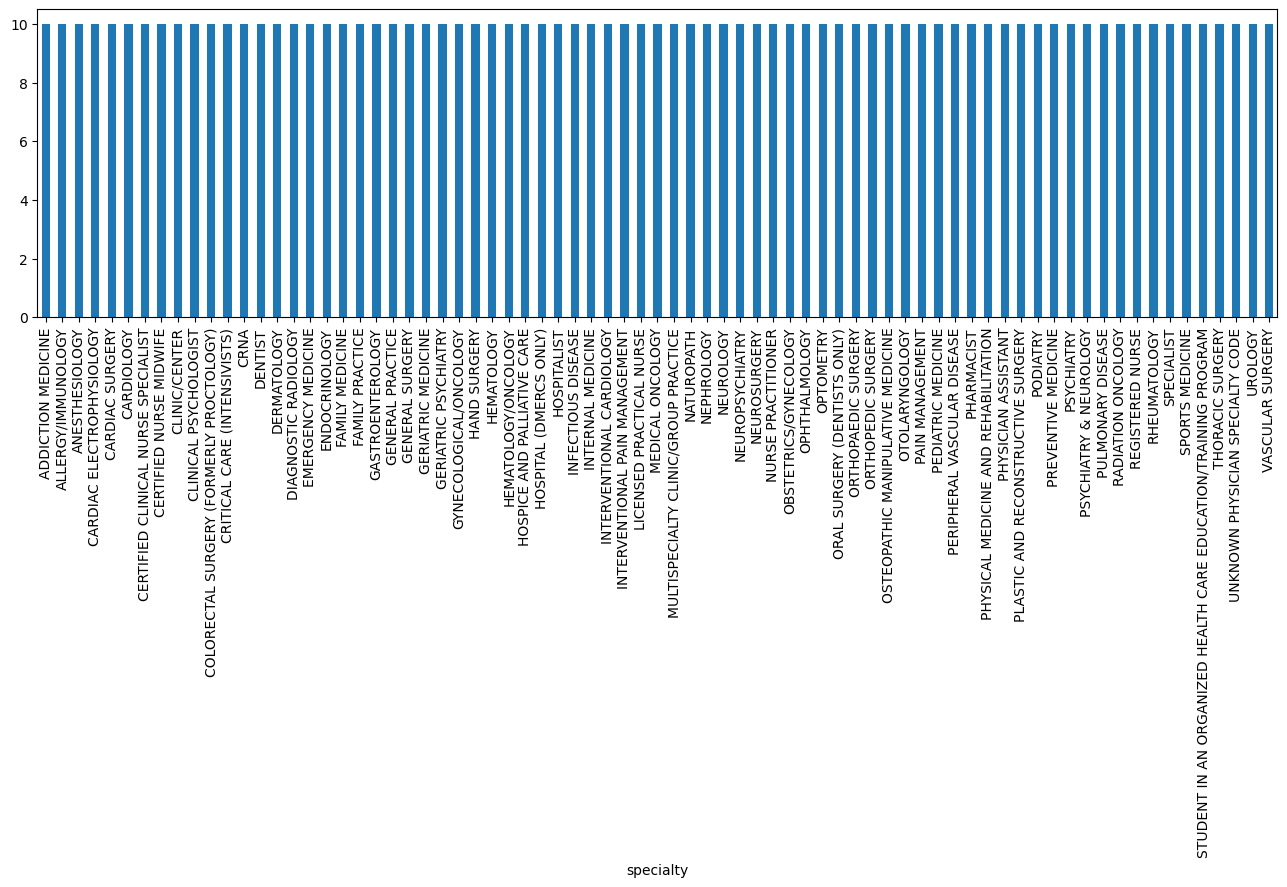

In [58]:
spending_subsampled_10n.groupby('specialty').size().plot.bar(figsize=(16, 4));

In [59]:
# Subset of original data containing 10 samples from each speciality category
# - "specialty" information is dropped
spending_subsampled_10n.reset_index((0,), drop=True)

,doctor_id,medication,nb_beneficiaries,spending,spending_pct
unique_id,,,,,
VG585760,1801032297,LAMOTRIGINE,11,82.62,8.979849
TX420809,1801032297,LORAZEPAM,14,19.56,2.125948
GJ278932,1134139991,BUSPIRONE HCL,49,817.88,88.894203
TX420809,1801032297,LORAZEPAM,14,19.56,2.125948
TX420809,1801032297,LORAZEPAM,14,19.56,2.125948
...,...,...,...,...,...
KL360002,1710981444,APIXABAN,14,4309.59,98.681300
KL360002,1710981444,APIXABAN,14,4309.59,98.681300
CU764903,1780885574,ACETAMINOPHEN WITH CODEINE,16,57.59,1.318700
